## 로컬 실행 준비

Colab 원본을 로컬 실행용으로 변환했습니다. 경로는 모두 `.env` 또는 저장소 상대 경로를 따릅니다.


In [ ]:
# ── 로컬 실행 설정 ───────────────────────────────────────────────
# 저장소 루트에서 실행하는 것을 전제로 합니다.
#   pip install -r requirements.txt
#   cp .env.example .env   후 키 입력
import os
from pathlib import Path
from dotenv import load_dotenv

load_dotenv()

REPO_ROOT   = Path(os.getenv("REPO_ROOT", Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()))
DATA_DIR    = Path(os.getenv("DATA_DIR",    REPO_ROOT / "data"))
RESULTS_DIR = Path(os.getenv("RESULTS_DIR", REPO_ROOT / "results"))
CHARTS_DIR  = RESULTS_DIR / "charts"
MODELS_DIR  = Path(os.getenv("MODELS_DIR",  REPO_ROOT / "models"))
for _d in (DATA_DIR, RESULTS_DIR, CHARTS_DIR, MODELS_DIR):
    _d.mkdir(parents=True, exist_ok=True)

GEMINI_API_KEY = os.getenv("GEMINI_API_KEY")
HF_TOKEN       = os.getenv("HF_TOKEN")
assert GEMINI_API_KEY, "GEMINI_API_KEY 미설정 — .env 를 확인하세요"

print(f"REPO_ROOT   = {REPO_ROOT}")
print(f"DATA_DIR    = {DATA_DIR}")
print(f"RESULTS_DIR = {RESULTS_DIR}")
print(f"MODELS_DIR  = {MODELS_DIR}")


In [ ]:
# Colab T4 GPU 환경 기준
# !pip install torch transformers datasets accelerate peft bitsandbytes trl "google-generativeai<0.8.0"
# !pip install git+https://github.com/huggingface/trl.git

# 기존 충돌 라이브러리 제거
# !pip uninstall -y transformers

# Gemma 3를 지원하는 '최신 개발자 버전' 설치 (GitHub 소스)

# 필수 의존성 업데이트

[Step 1] AI 피드백 데이터 생성 (AI Feedback)
Gemini를 심판으로 사용하여 Chosen(사실적 답변)과 Rejected(할루시네이션 답변)를 분류합니다.

In [ ]:
# =============================================================================
# [Step 1] RLAIF 데이터 생성 (스마트 이어하기 버전)
# =============================================================================
import json
import os
import sys

# 1. 먼저 데이터 상태부터 확인 (모델 로드 X)
# -----------------------------------------------------------------------------

DATA_DIR = str(DATA_DIR)
INPUT_FILES = ['truthfulqa_ko_250.json', 'kmmlu_qa_style_250.json']
OUTPUT_FILE = os.path.join(DATA_DIR, "rlaif_dataset_final.json")
ERROR_FILE = os.path.join(DATA_DIR, "rlaif_error_logs.json")

# 원본 데이터 개수 파악
total_input_count = 0
full_dataset = []

print("데이터 진행 상황 체크 중...")
for f_name in INPUT_FILES:
    # 현재 경로에 파일이 없으면 드라이브나 업로드 경로 확인
    if os.path.exists(f_name):
        path = f_name
    elif os.path.exists(os.path.join(DATA_DIR, f_name)):
        path = os.path.join(DATA_DIR, f_name)
    else:
        print(f"원본 파일 없음: {f_name}")
        continue

    with open(path, 'r', encoding='utf-8') as f:
        data = json.load(f)
        full_dataset.extend(data)
        total_input_count += len(data)

# 저장된 데이터 개수 파악
saved_count = 0
if os.path.exists(OUTPUT_FILE):
    with open(OUTPUT_FILE, 'r', encoding='utf-8') as f:
        try:
            saved_data = json.load(f)
            saved_count = len(saved_data)
        except:
            pass

print(f"현황: 총 {total_input_count}개 중 {saved_count}개 완료.")

# ★ 핵심: 이미 다 했으면 여기서 깔끔하게 끝냄 (모델 로드 안 함)
if saved_count >= total_input_count and total_input_count > 0:
    print("\n이미 모든 데이터 생성이 완료되었습니다!")
    print(f"파일 위치: {OUTPUT_FILE}")
    # sys.exit(0) 대신 그냥 더 이상 코드를 실행하지 않도록 구조화
    NEED_TO_RUN = False
else:
    print(f"\n{total_input_count - saved_count}개 데이터 생성을 시작합니다...")
    NEED_TO_RUN = True

# -----------------------------------------------------------------------------
# 2. 실제 생성 작업 (필요할 때만 실행)
# -----------------------------------------------------------------------------
if NEED_TO_RUN:
    # 필요한 라이브러리 임포트 (여기서 해야 시간 절약)
    import torch
    import time
    import google.generativeai as genai
    from tqdm import tqdm
    from huggingface_hub import login
    from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig

    # 설정
    GEMINI_API_KEY = os.getenv("GEMINI_API_KEY")
    HF_TOKEN = os.getenv("HF_TOKEN")
    MODEL_ID = "google/gemma-3-4b-it"
    BATCH_SIZE = 32
    SAVE_INTERVAL = 2

    login(token=HF_TOKEN)
    genai.configure(api_key=GEMINI_API_KEY)
    judge_model = genai.GenerativeModel('gemini-2.5-flash', generation_config={"temperature": 0.1, "response_mime_type": "application/json"})

    # 모델 로드
    print(f"[A100] 모델 로드 중...")
    bnb_config = BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_compute_dtype=torch.bfloat16,
        bnb_4bit_use_double_quant=True,
        bnb_4bit_quant_type="nf4"
    )

    tokenizer = AutoTokenizer.from_pretrained(MODEL_ID, trust_remote_code=True)
    if tokenizer.pad_token is None: tokenizer.pad_token = tokenizer.eos_token
    tokenizer.padding_side = "left"

    model = AutoModelForCausalLM.from_pretrained(
        MODEL_ID,
        quantization_config=bnb_config,
        device_map={"": 0},
        trust_remote_code=True,
        attn_implementation="flash_attention_2"
    )

    # 남은 데이터만 추출
    if saved_count > 0:
        with open(OUTPUT_FILE, "r", encoding='utf-8') as f:
            preference_data = json.load(f)
    else:
        preference_data = []

    remaining_dataset = full_dataset[saved_count:]

    # 배치 처리 함수
    def process_batch(batch_data):
        prompts = [item['prompt'] for item in batch_data]
        ground_truths = [item['ground_truth'] for item in batch_data]

        try:
            inputs = tokenizer(prompts, return_tensors="pt", padding=True, truncation=True, max_length=512).to("cuda")
            with torch.no_grad():
                outputs = model.generate(**inputs, max_new_tokens=256, do_sample=True, temperature=0.9, num_return_sequences=2, pad_token_id=tokenizer.pad_token_id)
            decoded = tokenizer.batch_decode(outputs, skip_special_tokens=True)
        except Exception as e:
            print(f"GPU 오류: {e}")
            return []

        new_results = []
        error_results = []

        for i, original_prompt in enumerate(prompts):
            ans_a = decoded[2*i].replace(original_prompt, "").strip()
            ans_b = decoded[2*i+1].replace(original_prompt, "").strip()

            judge_prompt = f"""Question: {original_prompt}\nGround Truth: {ground_truths[i]}\nAnswer A: {ans_a}\nAnswer B: {ans_b}\nWhich answer is more factually correct?\nOutput JSON only: {{"winner": "A"}} or {{"winner": "B"}}"""

            success = False
            for _ in range(5):
                try:
                    resp = judge_model.generate_content(judge_prompt)
                    res_json = json.loads(resp.text.replace("```json", "").replace("```", "").strip())
                    winner = res_json.get("winner")
                    if winner in ["A", "B"]:
                        new_results.append({"prompt": original_prompt, "chosen": ans_a if winner == "A" else ans_b, "rejected": ans_b if winner == "A" else ans_a})
                        success = True
                        break
                except:
                    time.sleep(1)

            if not success:
                error_results.append({"prompt": original_prompt, "error": "API Fail"})

        if error_results:
            with open(ERROR_FILE, "a", encoding='utf-8') as ef:
                for err in error_results:
                    ef.write(json.dumps(err, ensure_ascii=False) + "\n")

        return new_results

    # 실행 루프
    print(f"생성 시작! (남은 데이터: {len(remaining_dataset)}개)")
    batches = [remaining_dataset[i:i + BATCH_SIZE] for i in range(0, len(remaining_dataset), BATCH_SIZE)]

    for i, batch in enumerate(tqdm(batches)):
        results = process_batch(batch)
        preference_data.extend(results)

        if (i + 1) % SAVE_INTERVAL == 0:
            with open(OUTPUT_FILE, "w", encoding='utf-8') as f:
                json.dump(preference_data, f, indent=4, ensure_ascii=False)

    # 최종 저장
    with open(OUTPUT_FILE, "w", encoding='utf-8') as f:
        json.dump(preference_data, f, indent=4, ensure_ascii=False)
    print("완료!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
데이터 진행 상황 체크 중...
현황: 총 500개 중 500개 완료.

이미 모든 데이터 생성이 완료되었습니다!
파일 위치: /content/drive/MyDrive/rlaif_dataset_final.json


[Step 2] 보상 모델 학습 (Reward Modeling)
생성된 데이터를 이용해 "어떤 답변이 좋은지 점수를 매기는 모델(RM)"을 학습시킵니다.

In [ ]:
# =============================================================================
# [Step 2] 보상 모델 학습
# =============================================================================
import os
import sys

# 1. 구글 드라이브 연결 및 경로 설정

# 저장할 경로 (여기에 파일이 있으면 학습을 건너뜁니다)
OUTPUT_DIR = str(MODELS_DIR / "final_reward_model")
DATA_FILE = str(DATA_DIR / "rlaif_dataset_final.json")

# -----------------------------------------------------------------------------
# 2. 학습 건너뛰기 체크
# -----------------------------------------------------------------------------
if os.path.exists(OUTPUT_DIR) and os.path.exists(os.path.join(OUTPUT_DIR, "tokenizer.json")):
    print(f"\n[완료] 이미 학습된 보상 모델이 존재합니다: {OUTPUT_DIR}")
    print("학습을 건너뛰고 바로 Step 3로 넘어가셔도 좋습니다.")
    SKIP_TRAINING = True
else:
    print(f"\n학습된 모델이 없습니다. 학습을 시작합니다...")
    SKIP_TRAINING = False

# -----------------------------------------------------------------------------
# 3. 실제 학습 코드
# -----------------------------------------------------------------------------
if not SKIP_TRAINING:
    import os
    import torch
    import torch.distributed as dist
    import gc

    # 1) 환경 변수 초기화 (꼬임 방지)
    for key in ["MASTER_ADDR", "MASTER_PORT", "RANK", "WORLD_SIZE", "LOCAL_RANK"]:
        if key in os.environ:
            del os.environ[key]

    # 2) "나 혼자다(Single GPU)"라고 환경 변수 재설정
    os.environ["MASTER_ADDR"] = "127.0.0.1"
    os.environ["MASTER_PORT"] = "29500"
    os.environ["WORLD_SIZE"] = "1"
    os.environ["RANK"] = "0"

    # 3) 강제 초기화 (라이브러리 만족시키기)
    try:
        # 기존 그룹이 있다면 파괴
        if dist.is_initialized():
            dist.destroy_process_group()

        # 새로 초기화
        dist.init_process_group(backend="nccl", init_method="env://")
        print("Single-GPU용 프로세스 그룹 강제 초기화 완료.")

        # 메모리 정리
        torch.cuda.empty_cache()
        gc.collect()
    except Exception as e:
        print(f"초기화 중 메시지 (무시 가능): {e}")

    # --- 기존 코드 계속 ---
    import json
    from datasets import Dataset
    from trl import RewardTrainer, RewardConfig
    from peft import LoraConfig, TaskType
    from transformers import (
        AutoTokenizer,
        AutoModelForSequenceClassification,
        BitsAndBytesConfig
    )

    # 2. 설정
    MODEL_ID = "google/gemma-3-4b-it"

    # 4-bit 양자화 (A100 bfloat16)
    bnb_config = BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_compute_dtype=torch.bfloat16,
        bnb_4bit_use_double_quant=True,
        bnb_4bit_quant_type="nf4"
    )

    print(f"토크나이저 로드: {MODEL_ID}")
    tokenizer = AutoTokenizer.from_pretrained(MODEL_ID, trust_remote_code=True)
    tokenizer.pad_token = tokenizer.eos_token
    tokenizer.padding_side = "right"

    print(f"보상 모델(RM) 로드 중... (Gemma 3)")
    model = AutoModelForSequenceClassification.from_pretrained(
        MODEL_ID,
        quantization_config=bnb_config,
        device_map={"": 0},
        trust_remote_code=True,
        num_labels=1,
        attn_implementation="flash_attention_2",
        torch_dtype=torch.bfloat16
    )
    model.config.use_cache = False
    model.config.pad_token_id = tokenizer.pad_token_id

    # 3. 데이터셋 로드
    print(f"학습 데이터 로드: {DATA_FILE}")
    with open(DATA_FILE, "r", encoding='utf-8') as f:
        data = json.load(f)

    if len(data) < 300:
        data = data * 5 # 데이터 증강

    raw_dataset = Dataset.from_list(data)

    def preprocess_function(examples):
        new_examples = {
            "input_ids_chosen": [], "attention_mask_chosen": [],
            "input_ids_rejected": [], "attention_mask_rejected": [],
        }

        for prompt, chosen, rejected in zip(examples["prompt"], examples["chosen"], examples["rejected"]):
            # Chosen
            chosen_msg = [{"role": "user", "content": prompt}, {"role": "model", "content": chosen}]
            tokenized_c = tokenizer.apply_chat_template(chosen_msg, truncation=True, max_length=512, return_dict=True)

            # Rejected
            rejected_msg = [{"role": "user", "content": prompt}, {"role": "model", "content": rejected}]
            tokenized_r = tokenizer.apply_chat_template(rejected_msg, truncation=True, max_length=512, return_dict=True)

            new_examples["input_ids_chosen"].append(tokenized_c["input_ids"])
            new_examples["attention_mask_chosen"].append(tokenized_c["attention_mask"])
            new_examples["input_ids_rejected"].append(tokenized_r["input_ids"])
            new_examples["attention_mask_rejected"].append(tokenized_r["attention_mask"])

        return new_examples

    print("데이터 전처리 중...")
    tokenized_dataset = raw_dataset.map(preprocess_function, batched=True)

    # 4. Custom Collator (패딩 및 ID 주입)
    class GemmaRewardCollator:
        def __init__(self, tokenizer):
            self.tokenizer = tokenizer

        def __call__(self, features):
            batch = {}
            for key in ["chosen", "rejected"]:
                input_ids = [torch.tensor(f[f"input_ids_{key}"], dtype=torch.long) for f in features]
                attention_mask = [torch.tensor(f[f"attention_mask_{key}"], dtype=torch.long) for f in features]

                # 안전한 수동 패딩
                padded_input_ids = torch.nn.utils.rnn.pad_sequence(
                    input_ids, batch_first=True, padding_value=self.tokenizer.pad_token_id
                )
                padded_attention_mask = torch.nn.utils.rnn.pad_sequence(
                    attention_mask, batch_first=True, padding_value=0
                )

                batch[f"input_ids_{key}"] = padded_input_ids
                batch[f"attention_mask_{key}"] = padded_attention_mask
                # Gemma 3용 token_type_ids (0으로 채움)
                batch[f"token_type_ids_{key}"] = torch.zeros_like(padded_input_ids)
            return batch

    # 5. Custom Trainer (token_type_ids 전달)
    class GemmaRewardTrainer(RewardTrainer):
        def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
            rewards_chosen = model(
                input_ids=inputs["input_ids_chosen"],
                attention_mask=inputs["attention_mask_chosen"],
                token_type_ids=inputs["token_type_ids_chosen"],
                return_dict=True,
            ).logits

            rewards_rejected = model(
                input_ids=inputs["input_ids_rejected"],
                attention_mask=inputs["attention_mask_rejected"],
                token_type_ids=inputs["token_type_ids_rejected"],
                return_dict=True,
            ).logits

            rewards_chosen = rewards_chosen.squeeze(-1)
            rewards_rejected = rewards_rejected.squeeze(-1)
            loss = -torch.nn.functional.logsigmoid(rewards_chosen - rewards_rejected).mean()

            if return_outputs:
                return loss, {"rewards_chosen": rewards_chosen, "rewards_rejected": rewards_rejected}
            return loss

    # 6. 학습 설정 및 실행
    peft_config = LoraConfig(
        task_type=TaskType.SEQ_CLS,
        inference_mode=False,
        r=16, lora_alpha=32, lora_dropout=0.1,
        target_modules=["q_proj", "v_proj", "k_proj", "o_proj"],
        modules_to_save=["score"]
    )

    reward_config = RewardConfig(
        output_dir=str(MODELS_DIR / "reward_model_checkpoint"),
        per_device_train_batch_size=8,
        gradient_accumulation_steps=1,
        num_train_epochs=3,
        learning_rate=1e-5,
        max_length=512,
        bf16=True, fp16=False,
        gradient_checkpointing=True,
        logging_steps=10,
        report_to="none",
        save_strategy="no",
        remove_unused_columns=False
    )

    print("보상 모델 학습 시작... (Robust Ver.)")
    data_collator = GemmaRewardCollator(tokenizer=tokenizer)
    trainer = GemmaRewardTrainer(
        model=model,
        processing_class=tokenizer,
        args=reward_config,
        train_dataset=tokenized_dataset,
        peft_config=peft_config,
        data_collator=data_collator,
    )

    trainer.train()

    print(f"모델 저장 중... ({OUTPUT_DIR})")
    trainer.model.save_pretrained(OUTPUT_DIR)
    tokenizer.save_pretrained(OUTPUT_DIR)
    print("보상 모델 학습 및 저장 완료!")


[완료] 이미 학습된 보상 모델이 존재합니다: /content/drive/MyDrive/final_reward_model
학습을 건너뛰고 바로 Step 3로 넘어가셔도 좋습니다.


[Step 3] PPO 강화학습 (RLAIF 핵심)
학습된 보상 모델을 이용해, 원본 모델을 강화학습(PPO)시킵니다.

In [ ]:
# =============================================================================
# [Step 3] PPO 강화학습 (Stable Version: No Flash Attn)
# =============================================================================

# 1. 라이브러리 및 환경 설정 (이미 0.8.6으로 맞추셨으므로 초기화 코드만 실행)
import os
import torch
import torch.distributed as dist
import gc

# 환경 변수 클린업
for key in ["MASTER_ADDR", "MASTER_PORT", "RANK", "WORLD_SIZE", "LOCAL_RANK"]:
    if key in os.environ:
        del os.environ[key]

os.environ["MASTER_ADDR"] = "127.0.0.1"
os.environ["MASTER_PORT"] = "29500"
os.environ["WORLD_SIZE"] = "1"
os.environ["RANK"] = "0"

try:
    if not dist.is_initialized():
        dist.init_process_group(backend="nccl", init_method="env://")
        print("Process Group 초기화 완료.")
except:
    pass

torch.cuda.empty_cache()
gc.collect()

# -----------------------------------------------------------------------------
# 2. 라이브러리 및 설정
# -----------------------------------------------------------------------------
import json
from trl import PPOTrainer, PPOConfig, AutoModelForCausalLMWithValueHead, create_reference_model
from peft import LoraConfig, PeftModel
from transformers import (
    AutoTokenizer,
    BitsAndBytesConfig,
    AutoModelForCausalLM,
    AutoModelForSequenceClassification
)
from datasets import Dataset
from tqdm import tqdm

MODEL_ID = "google/gemma-3-4b-it"
REWARD_MODEL_PATH = str(MODELS_DIR / "final_reward_model")
DATA_FILE = str(DATA_DIR / "rlaif_dataset_final.json")

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.bfloat16,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4"
)

peft_config = LoraConfig(
    r=16, lora_alpha=32, lora_dropout=0.05, bias="none",
    task_type="CAUSAL_LM",
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj", "gate_proj", "up_proj", "down_proj"]
)

print(f"토크나이저 로드: {MODEL_ID}")
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID, trust_remote_code=True)
tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "left"

# -----------------------------------------------------------------------------
# 3. 모델 로드
# -----------------------------------------------------------------------------
print("베이스 모델 로드 중... (Standard Attention)")
base_model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    quantization_config=bnb_config,
    device_map={"": 0},
    trust_remote_code=True,
    # attn_implementation="flash_attention_2",
    torch_dtype=torch.bfloat16
)

if not hasattr(base_model.config, "hidden_size"):
    base_model.config.hidden_size = base_model.get_input_embeddings().weight.shape[1]

print("정책 모델 변환 중...")
policy_model = AutoModelForCausalLMWithValueHead.from_pretrained(base_model, peft_config=peft_config)

# Value Head를 강제로 bfloat16으로 변환하여 충돌 방지
policy_model.v_head.to(torch.bfloat16)

print("참조 모델 생성 중...")
ref_model = create_reference_model(policy_model)

# -----------------------------------------------------------------------------
# 4. 데이터셋
# -----------------------------------------------------------------------------
print(f"데이터 로드: {DATA_FILE}")
with open(DATA_FILE, "r", encoding='utf-8') as f:
    data = json.load(f)

dataset = Dataset.from_dict({"query": [item['prompt'] for item in data]})

def tokenize(sample):
    sample["input_ids"] = tokenizer.encode(sample["query"], padding="max_length", max_length=128, truncation=True)
    return sample

dataset = dataset.map(tokenize, batched=False)
dataset.set_format(type="torch")

# -----------------------------------------------------------------------------
# 5. 보상 모델 로드
# -----------------------------------------------------------------------------
print("보상 모델 로드 중...")
rm_base = AutoModelForSequenceClassification.from_pretrained(
    MODEL_ID,
    quantization_config=bnb_config,
    device_map={"": 0},
    trust_remote_code=True,
    num_labels=1,
    # attn_implementation="flash_attention_2",
    torch_dtype=torch.bfloat16
)
reward_model = PeftModel.from_pretrained(rm_base, REWARD_MODEL_PATH)
reward_model.eval()

# -----------------------------------------------------------------------------
# 6. PPO 학습 실행
# -----------------------------------------------------------------------------
print("PPO 학습 시작...")

ppo_config = PPOConfig(
    learning_rate=1.41e-5,
    batch_size=16,
    mini_batch_size=4,
    gradient_accumulation_steps=1,
    ppo_epochs=4,
    seed=42,
)

ppo_trainer = PPOTrainer(
    config=ppo_config,
    model=policy_model,
    ref_model=ref_model,
    tokenizer=tokenizer,
    dataset=dataset,
    data_collator=None
)

generation_kwargs = {
    "min_length": -1, "top_k": 0.0, "top_p": 1.0, "do_sample": True,
    "pad_token_id": tokenizer.pad_token_id, "max_new_tokens": 128,
}

# 보상 계산 함수 (Gemma 3 안전성 강화)
def get_reward_score(texts, model, tokenizer):
    # Gemma 3는 입력에 민감하므로 token_type_ids를 명시적으로 처리
    inputs = tokenizer(
        texts,
        return_tensors="pt",
        padding=True,
        truncation=True,
        max_length=512
    ).to(model.device)

    # 만약 tokenizer가 token_type_ids를 안 만들어줬으면 수동으로 생성 (전부 0)
    if "token_type_ids" not in inputs:
        inputs["token_type_ids"] = torch.zeros_like(inputs["input_ids"])

    with torch.no_grad():
        outputs = model(**inputs)
        scores = outputs.logits.squeeze(-1)
    return scores

print("PPO 학습 재개 (Gemma 3 Mode Switching 적용)...")

# 학습 루프
for epoch, batch in tqdm(enumerate(ppo_trainer.dataloader)):
    query_tensors = batch["input_ids"]
    query_list = [t for t in query_tensors]

    # -------------------------------------------------------------------------
    # 1. 답변 생성 (Generation)
    # -------------------------------------------------------------------------
    # 생성할 때는 '평가 모드(Eval)'로 전환
    ppo_trainer.model.eval()

    # 생성 실행
    response_tensors = ppo_trainer.generate(query_list, return_prompt=False, **generation_kwargs)

    batch["response"] = tokenizer.batch_decode(response_tensors, skip_special_tokens=True)
    batch["query"] = tokenizer.batch_decode(query_list, skip_special_tokens=True)

    # -------------------------------------------------------------------------
    # 2. 보상 계산 (Reward)
    # -------------------------------------------------------------------------
    texts = [q + r for q, r in zip(batch["query"], batch["response"])]
    rewards_tensor = get_reward_score(texts, reward_model, tokenizer)
    rewards = [r for r in rewards_tensor]

    # -------------------------------------------------------------------------
    # 3. 업데이트 (Step)
    # -------------------------------------------------------------------------
    #  학습할 때는 다시 '학습 모드(Train)'로 복귀!
    ppo_trainer.model.train()

    stats = ppo_trainer.step(query_list, response_tensors, rewards)

    # 로그 출력
    if epoch % 5 == 0:
        print(f"Epoch: {epoch}, Reward Mean: {torch.stack(rewards).mean().item():.4f}")

# 저장
print("최종 PPO 모델 저장 중...")
ppo_trainer.save_pretrained(str(MODELS_DIR / "final_ppo_model"))
tokenizer.save_pretrained(str(MODELS_DIR / "final_ppo_model"))
print("모든 학습이 정상적으로 완료되었습니다!")

토크나이저 로드: google/gemma-3-4b-it
베이스 모델 로드 중... (Standard Attention)


Loading weights:   0%|          | 0/883 [00:00<?, ?it/s]

정책 모델 변환 중...
참조 모델 생성 중...
데이터 로드: /content/drive/MyDrive/rlaif_dataset_final.json


Map:   0%|          | 0/500 [00:00<?, ? examples/s]

보상 모델 로드 중...


...

26it [49:41, 114.73s/it]

Epoch: 25, Reward Mean: -1.7109


31it [59:15, 114.69s/it]

Epoch: 30, Reward Mean: -0.5938
최종 PPO 모델 저장 중...


모든 학습이 정상적으로 완료되었습니다!


[Step 4] 최종 평가 (Evaluation) 및 지표 산출
PPT에 들어갈 '결과 그래프'를 위한 지표를 뽑습니다.

1단계: PPO 모델 답변 생성 및 Gemini 자동 채점

In [ ]:
# [Cell 1] PPO 모델 답변 생성 및 Gemini 평가 (Gemma 3 호환 패치)
import json
import google.generativeai as genai
import torch
from tqdm import tqdm
import time
import re
import os
from peft import PeftModel
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig

# =========================
# 1. 사용자 설정 (PPO 팀 맞춤)
# =========================
GEMINI_API_KEY = os.getenv("GEMINI_API_KEY")

# 학습된 PPO 모델 경로
ADAPTER_PATH = str(MODELS_DIR / "final_ppo_model")

# 평가 데이터 및 결과 파일
EVAL_INPUT_FILE = str(DATA_DIR / "evaluation_dataset_50.json")
RESULT_FILE = str(RESULTS_DIR / "eval_ppo.json")
MODEL_NAME = "google/gemma-3-4b-it"

# =========================
# 2. Gemini 및 모델 설정
# =========================
genai.configure(api_key=GEMINI_API_KEY)
JUDGE_MODEL = "gemini-2.5-flash" # 또는 2.0-flash
judge_model = genai.GenerativeModel(JUDGE_MODEL)

print(f"PPO 모델 로딩 중: {ADAPTER_PATH}")
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True
)

try:
    # Gemma 3 토크나이저 로드
    tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
    tokenizer.pad_token = tokenizer.eos_token
    tokenizer.padding_side = "left"

    base_model = AutoModelForCausalLM.from_pretrained(
        MODEL_NAME,
        quantization_config=bnb_config,
        device_map="auto"
    )

    if os.path.exists(ADAPTER_PATH):
        model = PeftModel.from_pretrained(base_model, ADAPTER_PATH)
        print("PPO 어댑터(LoRA) 로드 성공!")
    else:
        print(f"PPO 모델 경로가 잘못되었습니다: {ADAPTER_PATH}")
        model = base_model

    model.eval()

except Exception as e:
    print(f"모델 로드 실패: {e}")
    raise e

# =========================
# 3. 데이터 로드
# =========================
if not os.path.exists(EVAL_INPUT_FILE):
    print(f"평가 데이터 파일이 없습니다: {EVAL_INPUT_FILE}")
else:
    with open(EVAL_INPUT_FILE, "r", encoding="utf-8") as f:
        eval_data = json.load(f)

# =========================
# 4. PPO 추론 함수
# =========================
def generate_ppo_answer(prompt: str) -> str:
    messages = [{"role": "user", "content": prompt}]

    # 1. 입력을 변수 'inputs'로 받음 (텐서일 수도, 딕셔너리일 수도 있음)
    inputs = tokenizer.apply_chat_template(
        messages,
        add_generation_prompt=True,
        return_tensors="pt",
        return_dict=True # 명시적으로 딕셔너리 요청
    ).to(model.device)

    # 2. 진짜 input_ids 텐서 추출 (Gemma 3 호환성 확보)
    if isinstance(inputs, torch.Tensor):
        input_ids = inputs
        model_inputs = {"input_ids": inputs}
    else:
        # BatchEncoding(딕셔너리)인 경우
        input_ids = inputs["input_ids"]
        model_inputs = inputs # 전체를 그대로 전달 (input_ids, attention_mask 등 포함)

    # 3. 생성
    with torch.no_grad():
        outputs = model.generate(
            **model_inputs, # unpack 해서 전달
            max_new_tokens=256,
            do_sample=False,
            pad_token_id=tokenizer.eos_token_id,
            eos_token_id=tokenizer.eos_token_id,
            repetition_penalty=1.1
        )

    # 4. 슬라이싱 (프롬프트 길이만큼 잘라내기)
    # 이제 input_ids는 확실히 텐서이므로 .shape 접근 가능
    generated_tokens = outputs[0][input_ids.shape[-1]:]
    return tokenizer.decode(generated_tokens, skip_special_tokens=True).strip()

# =========================
# 5. Gemini 채점 함수
# =========================
def evaluate_with_gemini(prompt, ground_truth, prediction):
    judge_prompt = f"""
당신은 AI 모델 답변을 채점하는 엄격한 심사위원입니다.
아래 [질문]에 대한 [모델 답변]을 [정답]과 비교하여 점수를 매겨주세요.

---
[질문]: {prompt}
[정답]: {ground_truth}
[모델 답변]: {prediction}
---

[채점 기준 (각 0~10점)]
1. 정확성(Accuracy): 정답과 의미가 일치하고 환각이 없는가? (틀리면 0점)
2. 간결성(Conciseness): 불필요한 서론/반복 없이 핵심만 답했는가?

[출력 형식]
반드시 JSON 형식으로만 출력하세요:
{{
  "accuracy": 0~10,
  "conciseness": 0~10,
  "reason": "평가 이유"
}}
"""
    for attempt in range(3):
        try:
            response = judge_model.generate_content(
                judge_prompt,
                generation_config={"temperature": 0.0, "response_mime_type": "application/json"}
            )
            text = response.text.replace("```json", "").replace("```", "").strip()
            match = re.search(r"\{.*\}", text, re.DOTALL)
            if match:
                return json.loads(match.group())
        except Exception as e:
            time.sleep(1)
    return {"accuracy": 0, "conciseness": 0, "reason": "Evaluation Failed"}

# =========================
# 6. 실행 루프
# =========================
results = []
print(f"PPO 평가 시작 (총 {len(eval_data)}개)...")

for idx, item in enumerate(tqdm(eval_data)):
    prompt = item["prompt"]
    ground_truth = item.get("ground_truth", "")

    # 1) PPO 답변 생성
    ppo_answer = generate_ppo_answer(prompt)

    # 2) Gemini 채점
    judgment = evaluate_with_gemini(prompt, ground_truth, ppo_answer)

    results.append({
        "prompt": prompt,
        "ground_truth": ground_truth,
        "prediction": ppo_answer,
        "accuracy": judgment.get("accuracy", 0),
        "conciseness": judgment.get("conciseness", 0),
        "reason": judgment.get("reason", "")
    })
    time.sleep(0.5)

# 저장
with open(RESULT_FILE, "w", encoding="utf-8") as f:
    json.dump(results, f, ensure_ascii=False, indent=2)

print("PPO 평가 완료!")
print(f"저장됨: {RESULT_FILE}")

PPO 모델 로딩 중: /content/drive/MyDrive/final_ppo_model


Loading weights:   0%|          | 0/883 [00:00<?, ?it/s]

PPO 어댑터(LoRA) 로드 성공!
PPO 평가 시작 (총 50개)...


100%|██████████| 50/50 [43:43<00:00, 52.47s/it]

PPO 평가 완료!
저장됨: /content/drive/MyDrive/ppo_evaluation_result.json


2단계: 결과 시각화 (Base vs PPO)

Base 모델 샘플 수: 50
PPO  모델 샘플 수: 50

[최종 점수 비교]
Base Pts: 13.90점
PPO  Pts: 8.00점



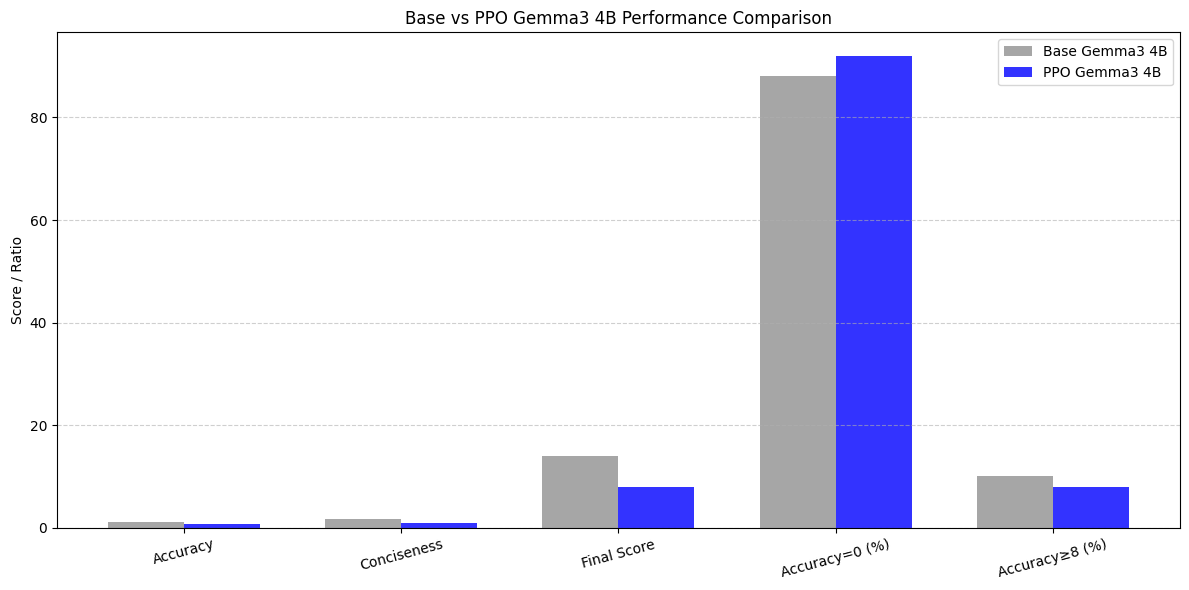

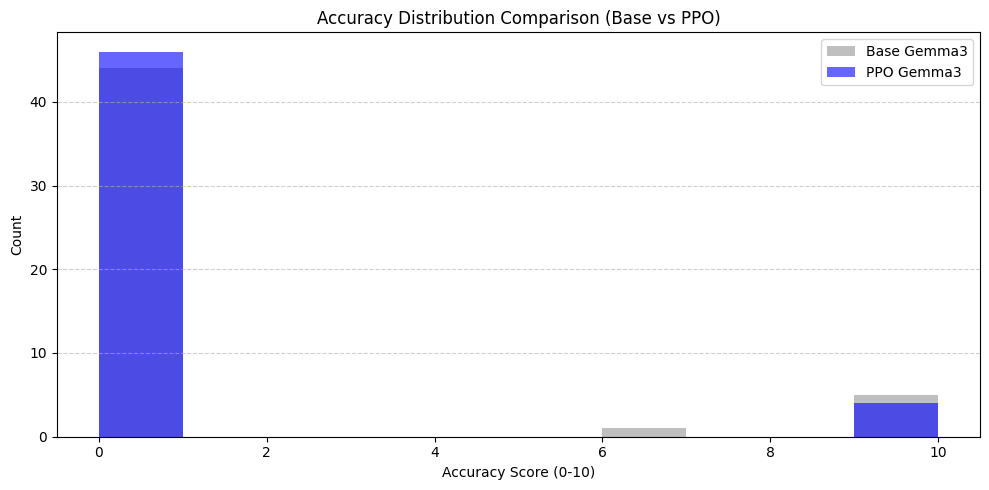

그래프 생성 완료
저장 파일:
 - base_vs_ppo_comparison.png
 - accuracy_distribution_ppo.png


In [ ]:
# [Cell 2] Base vs PPO 성능 비교 시각화
import json
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os

# =========================
# 1. 파일 설정 (PPO vs Base)
# =========================
# Base 모델 결과 파일
BASE_FILE = str(RESULTS_DIR / "eval_base_4b.json")
# 방금 생성한 PPO 결과 파일
PPO_FILE  = str(RESULTS_DIR / "eval_ppo.json")

# Base 파일이 없으면 더미 데이터로 에러 방지 (실제로는 파일이 있어야 함)
if not os.path.exists(BASE_FILE):
    print(f"Base 모델 결과 파일이 없습니다: {BASE_FILE}")
    print("비교를 위해 Base 모델 결과가 필요합니다. 일단 PPO 결과만 로드합니다.")
    base_data = []
else:
    with open(BASE_FILE, "r", encoding="utf-8") as f:
        base_data = json.load(f)

with open(PPO_FILE, "r", encoding="utf-8") as f:
    ppo_data = json.load(f)

df_base = pd.DataFrame(base_data)
df_ppo  = pd.DataFrame(ppo_data)

print(f"Base 모델 샘플 수: {len(df_base)}")
print(f"PPO  모델 샘플 수: {len(df_ppo)}")

# =========================
# 2. 지표 계산
# =========================
def calc_metrics(df):
    if len(df) == 0: return 0, 0, 0, 0, 0
    avg_acc = df["accuracy"].mean()
    avg_con = df["conciseness"].mean()
    final_score = ((avg_acc + avg_con) / 2) * 10
    zero_acc = (df["accuracy"] == 0).mean() * 100
    high_acc = (df["accuracy"] >= 8).mean() * 100
    return avg_acc, avg_con, final_score, zero_acc, high_acc

base_metrics = calc_metrics(df_base)
ppo_metrics  = calc_metrics(df_ppo)

# 콘솔 출력
print("\n" + "="*40)
print("[최종 점수 비교]")
print(f"Base Pts: {base_metrics[2]:.2f}점")
print(f"PPO  Pts: {ppo_metrics[2]:.2f}점")
print("="*40 + "\n")

labels = ["Accuracy", "Conciseness", "Final Score", "Accuracy=0 (%)", "Accuracy≥8 (%)"]
base_values = list(base_metrics)
ppo_values  = list(ppo_metrics)

# =========================
# 3. 막대 그래프 (Base vs PPO)
# =========================
x = np.arange(len(labels))
width = 0.35

plt.figure(figsize=(12, 6))
plt.bar(x - width/2, base_values, width, label="Base Gemma3 4B", color='gray', alpha=0.7)
plt.bar(x + width/2, ppo_values,  width, label="PPO Gemma3 4B", color='blue', alpha=0.8)

plt.xticks(x, labels, rotation=15)
plt.ylabel("Score / Ratio")
plt.title("Base vs PPO Gemma3 4B Performance Comparison")
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.6)

plt.tight_layout()
plt.savefig(str(CHARTS_DIR / "base_vs_ppo_comparison.png"), dpi=200)
plt.show()

# =========================
# 4. Accuracy 분포 비교
# =========================
plt.figure(figsize=(10, 5))
if not df_base.empty:
    plt.hist(df_base["accuracy"], bins=10, alpha=0.5, label="Base Gemma3", color='gray')
plt.hist(df_ppo["accuracy"],  bins=10, alpha=0.6, label="PPO Gemma3", color='blue')

plt.xlabel("Accuracy Score (0-10)")
plt.ylabel("Count")
plt.title("Accuracy Distribution Comparison (Base vs PPO)")
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.6)

plt.tight_layout()
plt.savefig(str(CHARTS_DIR / "accuracy_distribution_ppo.png"), dpi=200)
plt.show()

print("그래프 생성 완료")
print("저장 파일:")
print(" - base_vs_ppo_comparison.png")
print(" - accuracy_distribution_ppo.png")